In [1]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [ ]:
# Configuration and paths
mac = 20

# Initial the exp assay path variable
exp_anno_local = None

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, core_promoter
# ============================================================
variant_class = 'missense'
exclude_clinvar = False  # Independent toggle: exclude ClinVar-annotated variants

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/config_variant_classes.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Exclude ClinVar: {exclude_clinvar}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_expAssays.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

In [2]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set


Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000067900""","""lymphocyte_count_int""",0.015659,-0.097882,0.097882,-1.0
"""ENSG00000145386""","""mean_corpuscular_haemoglobin_i…",0.000096,-0.059845,0.059845,-1.0
"""ENSG00000164944""","""trunk_predicted_mass_int""",0.015511,-0.04623,0.04623,-1.0
"""ENSG00000107863""","""trunk_predicted_mass_int""",0.033889,-0.122605,0.122605,-1.0
"""ENSG00000121966""","""eosinophill_percentage_int""",0.000392,-0.075765,0.075765,-1.0
…,…,…,…,…,…
"""ENSG00000142208""","""arm_predicted_mass_right_int""",0.009537,-0.049973,0.049973,-1.0
"""ENSG00000101670""","""cholesterol_int""",0.000099,0.035791,0.035791,1.0
"""ENSG00000017427""","""weight_int""",0.000158,-0.170599,0.170599,-1.0


In [4]:
# # aPCA assay

# gene_id = "ENSG00000136068" # FLNB. Beltran et al. Nature. 2025
# pheno = 'standing_height_int'
# assay2plot = 'scaled_fitness'

# LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"

# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/experimental_assays/aPCA_Beltran_Nature_2025.parquet -o {LOCAL_EXP_DIR}

# exp_anno_local = f"{LOCAL_EXP_DIR}/aPCA_Beltran_Nature_2025.parquet"

# id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']
# # One fitness score per variant, 447 genes
# exp_anno_df = (
#     pl.read_parquet(exp_anno_local)
#     .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
#     .drop_nulls()
#     .group_by(id_cols).agg(pl.col('scaled_fitness').mean())
# )

# exp_assay_columns = ['scaled_fitness']
# exp_anno_df


In [5]:
# Marsh assays

# gene_id = "ENSG00000106633" # GCK. Gersing et al. A comprehensive map of human glucokinase variant activity. Genome Biol. 2023;24:97.
# pheno = 'glycated_haemoglobin_hba1c_int'
# assay2plot = 'DMS'

# gene_id = "ENSG00000132170" # PPARG. Majithia et al. Prospective functional classification of all possible missense variants in PPARG. Nat Genet. 2016;48:1570–5.
# pheno = 'hdl_cholesterol_int'
# assay2plot = "DMS"

# gene_id = "ENSG00000171862" # PTEN (DMS_highqual_b). Matreyek et al (2018) Multiplex assessment of protein variant abundance by massively parallel sequencing. Nat Genet 50: 874–882
# pheno = 'igf1_int'
# assay2plot = 'DMS_highqual_b'

# exp_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/experimental_assays"

# exp_anno_filename = "DMS_Marsh_VEP.parquet"
# exp_assay_type_column = 'DMS_assay'
# exp_assay_score_column = 'DMS_score'

# LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"
# !mkdir -p {LOCAL_EXP_DIR}
# !dx download {exp_anno_path}/{exp_anno_filename} -o {LOCAL_EXP_DIR}

# exp_anno_local = f'{LOCAL_EXP_DIR}/{exp_anno_filename}'

# id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']
# exp_anno_df = (
#     pl.read_parquet(exp_anno_local)
#     .filter(pl.col('region')==gene_id)
#     .drop_nulls(subset=id_cols)
#     .pivot(
#         index=id_cols,
#         on=exp_assay_type_column,
#         values=exp_assay_score_column
#     )
# )

# exp_assay_columns = list(set(exp_anno_df.columns) - set(id_cols))
# exp_anno_df = exp_anno_df.select(id_cols + exp_assay_columns)

# exp_anno_df

In [6]:
gene_id = "ENSG00000130164" # LDLR. Roth et al. Science 2025
pheno = 'ldl_direct_int'
assay2plot = 'LDL_uptake_functional'

exp_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/experimental_assays"

exp_anno_filename = "LDLR_Roth_Science_2025.parquet"
exp_assay_type_column = 'assay'
exp_assay_score_column = 'score'

LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"
!mkdir -p {LOCAL_EXP_DIR}
!dx download {exp_anno_path}/{exp_anno_filename} -o {LOCAL_EXP_DIR}

exp_anno_local = f'{LOCAL_EXP_DIR}/{exp_anno_filename}'

id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']
exp_anno_df = (
    pl.read_parquet(exp_anno_local)
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .drop_nulls(subset=id_cols)
    # .select(id_cols + exp_assay_type_columns + exp_assay_score_columns)
    .pivot(
        index=id_cols,
        on=exp_assay_type_column,
        values=exp_assay_score_column
    )
)

exp_assay_columns = list(set(exp_anno_df.columns) - set(id_cols))
exp_assay_columns = ['LDL_uptake_functional', 'LDLR_cell_surface_abundance']

exp_anno_df = exp_anno_df.select(id_cols + exp_assay_columns)

exp_anno_df

[===========================================================>] Completed 1,373,862 of 1,373,862 bytes (100%) /home/dnanexus/data_dir/experimental_assays/LDLR_Roth_Science_2025.parquett


/tmp/ipykernel_45947/1210023228.py:20: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


ref_aa,aa_position,alt_aa,region,LDL_uptake_functional,LDLR_cell_surface_abundance
str,i64,str,str,f64,f64
"""G""",2,"""L""","""ENSG00000130164""",-0.042187,0.90099
"""G""",2,"""W""","""ENSG00000130164""",0.985631,1.012781
"""G""",2,"""A""","""ENSG00000130164""",0.964176,1.021534
"""G""",2,"""Y""","""ENSG00000130164""",-0.026747,1.062286
"""G""",2,"""M""","""ENSG00000130164""",1.012579,1.130779
…,…,…,…,…,…
"""G""",343,"""Q""","""ENSG00000130164""",null,null
"""A""",348,"""W""","""ENSG00000130164""",null,null
"""A""",348,"""Y""","""ENSG00000130164""",null,null


In [7]:
gene_trait_df = (
    gene_trait_df
    .filter(
        pl.col('region') == gene_id,
        pl.col('phenotype') == pheno
    )
)

gene_trait_df

region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000130164""","""ldl_direct_int""",3.0392e-14,0.104534,0.104534,1.0


In [ ]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Join new annotation if specified above
if exp_anno_local is not None:
    anno = (
        anno
        .filter(
            pl.col('amino_acids').is_not_null(),
            pl.col('amino_acids').str.contains("/"),
            ~pl.col('protein_position').str.contains("-")
        )
        .with_columns(
            pl.col("amino_acids").str.split("/").list.get(0).alias("ref_aa"),
            pl.col("amino_acids").str.split("/").list.get(1).alias("alt_aa"),
            pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
        )

        .join(
            exp_anno_df.lazy(),
            on=['ref_aa', 'aa_position', 'alt_aa', 'region'],
            how='left'
        )

        # Restrict to variants with experimental assay data
        .drop_nulls(exp_assay_columns)
    )

# Build dynamic filters from variant_class.yaml
_dynamic_filters = [eval(f) for f in vc_filters]
if exclude_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_null())

anno = (
    anno
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
)

selected_categories = ['missense', 'genetic_diversity', 'conservation'] # missense
# selected_categories = ['protein_domains'] # protein domains
# selected_categories = ['loftee_protein_domains'] # protein domains
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # synonymous
# selected_categories = ['plof', 'missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # CDS

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

selected_annos = list(set(selected_annos).intersection(set(existing_annos))) + exp_assay_columns
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

In [9]:
melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
        
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    
    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr19:11105249:C:T""","""ENSG00000130164""","""cpt1_llr""",0.472214
"""chr19:11105309:T:G""","""ENSG00000130164""","""cpt1_llr""",0.144248
"""chr19:11105379:C:T""","""ENSG00000130164""","""cpt1_llr""",0.474107
"""chr19:11105270:A:C""","""ENSG00000130164""","""cpt1_llr""",0.197952
"""chr19:11105270:A:G""","""ENSG00000130164""","""cpt1_llr""",0.072292
…,…,…,…
"""chr19:11123322:G:T""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",0.942537
"""chr19:11123212:G:A""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",0.893775
"""chr19:11123200:G:A""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",0.953498


In [10]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


In [11]:
from scipy.stats import spearmanr, norm

ci_alpha = 0.05
z_crit = norm.ppf(1 - ci_alpha / 2)  # 1.96 for 95% CI

# --- 1. Collect the pre-correlation data ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())

pre_corr_data = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_na' in c]),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df["region", "phenotype"].lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .filter(pl.col('annotation') != 'loftee_hc')
    .collect(engine='streaming')
)

pre_corr_data

id,phenotype,mean_pheno_value,n_individuals,region,annotation,annotation_score
str,str,f32,i32,str,str,f32
"""chr19:11105470:C:G""","""ldl_direct_int""",2.011034,2,"""ENSG00000130164""","""cpt1_llr""",null
"""chr19:11105470:C:G""","""ldl_direct_int""",2.011034,2,"""ENSG00000130164""","""verphylop""",-0.151
"""chr19:11105470:C:G""","""ldl_direct_int""",2.011034,2,"""ENSG00000130164""","""esmscoremissense""",0.0
"""chr19:11105470:C:G""","""ldl_direct_int""",2.011034,2,"""ENSG00000130164""","""esm1b_llr""",null
"""chr19:11105470:C:G""","""ldl_direct_int""",2.011034,2,"""ENSG00000130164""","""cadd_raw""",3.922757
…,…,…,…,…,…,…
"""chr19:11116936:C:T""","""ldl_direct_int""",0.88713,13,"""ENSG00000130164""","""verphylop""",0.347
"""chr19:11116936:C:T""","""ldl_direct_int""",0.88713,13,"""ENSG00000130164""","""esmscoremissense""",-11.073
"""chr19:11116936:C:T""","""ldl_direct_int""",0.88713,13,"""ENSG00000130164""","""esm1b_llr""",-10.748


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 14 rows containing missing values.


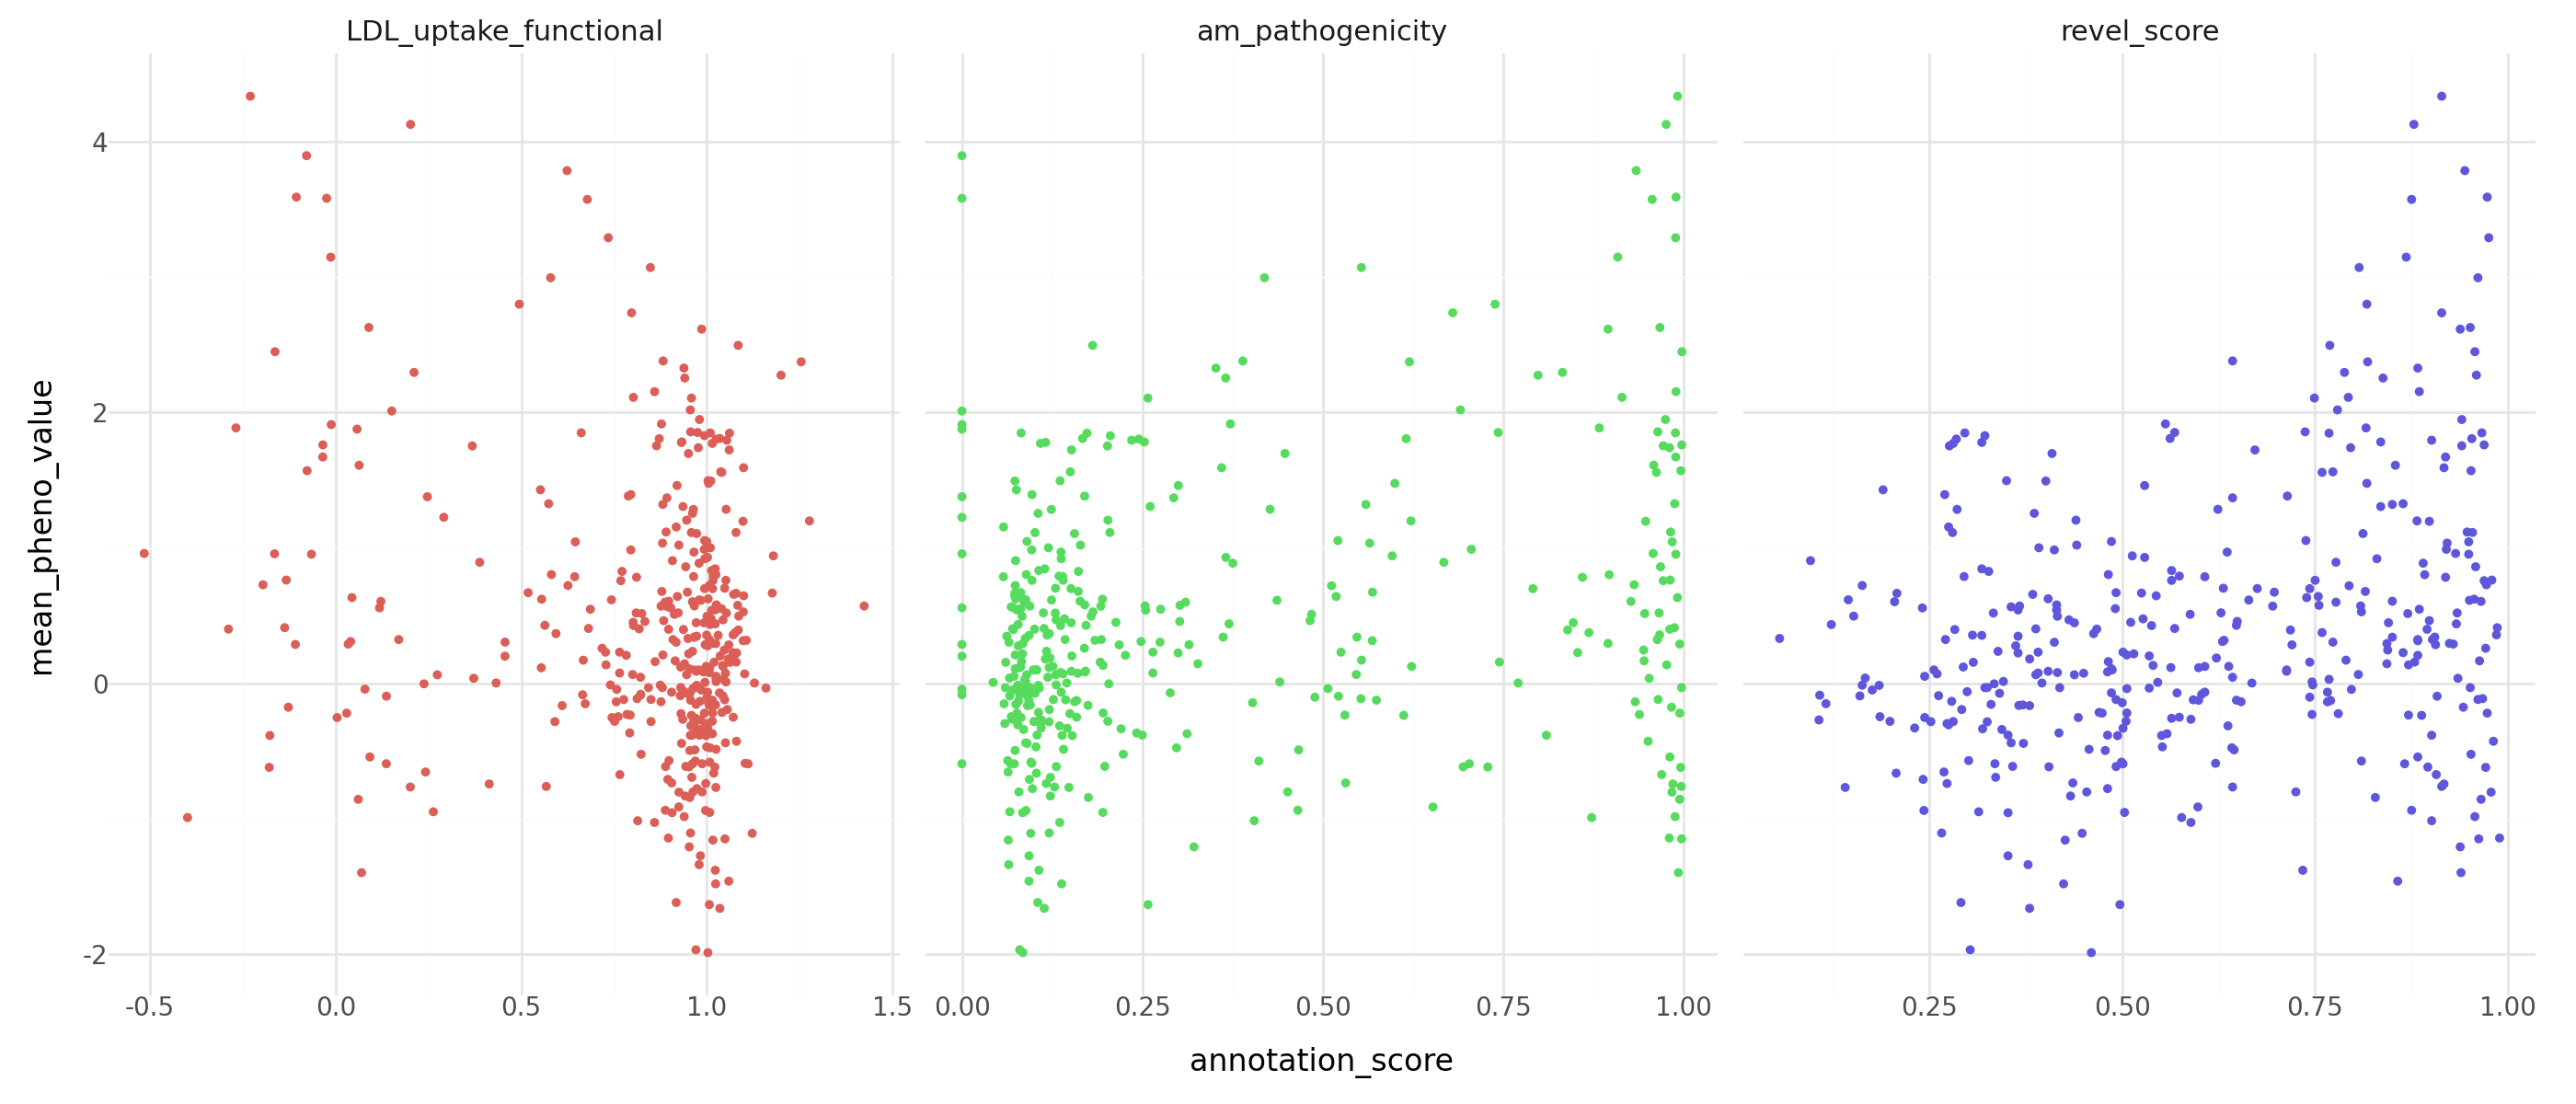

In [12]:
(
    ggplot(
        pre_corr_data.filter(pl.col('annotation').is_in(['phenotype', assay2plot, 'am_pathogenicity', 'revel_score'])), 
        aes(x='annotation_score', y='mean_pheno_value', color='annotation')
    )
    + geom_point(size=1)
    + facet_wrap("~annotation", nrow=1, scales="free_x")
    + theme_minimal()
    + theme(
        figure_size=(14, 6),
        legend_position="none",
        axis_text=element_text(size=10),
        axis_title=element_text(size=12),
        strip_text=element_text(size=11),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [13]:
anno_df = pre_corr_data[['id', 'region', 'annotation', 'annotation_score']].unique()

pheno_df = (
    pre_corr_data[['id', 'region', 'mean_pheno_value']]
    .unique()
    .rename({'mean_pheno_value': 'annotation_score'})
    .with_columns(
        annotation = pl.lit('phenotype')
    )
    .select(['id', 'region', 'annotation', 'annotation_score'])
)

anno_df = pl.concat([anno_df, pheno_df], how='vertical')

# Get variant ID to amino acid position mapping from the annotation parquet
anno_with_pos = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .filter(
        pl.col('amino_acids').is_not_null(),
        pl.col('amino_acids').str.contains("/"),
        ~pl.col('protein_position').str.contains("-"),
        pl.col('region').is_in(gene_trait_df['region'].unique()),
    )
    .with_columns(
        pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
    )
    .select(['id', 'aa_position'])
    .unique()
    .collect()
)

# Add position to pre_corr_data
anno_df = anno_df.join(anno_with_pos, on='id', how='inner')
anno_df

/tmp/ipykernel_45947/2532201640.py:29: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,aa_position
str,str,str,f32,i64
"""chr19:11105569:C:G""","""ENSG00000130164""","""cpt1_llr""",0.474721,221
"""chr19:11105470:C:G""","""ENSG00000130164""","""am_pathogenicity""",0.0,188
"""chr19:11120391:C:A""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",1.026235,670
"""chr19:11123195:C:T""","""ENSG00000130164""","""LDL_uptake_functional""",1.012649,721
"""chr19:11113743:G:A""","""ENSG00000130164""","""gpn_score""",-5.7,523
…,…,…,…,…
"""chr19:11105390:C:T""","""ENSG00000130164""","""phenotype""",2.106396,162
"""chr19:11105331:C:T""","""ENSG00000130164""","""phenotype""",-1.480486,142
"""chr19:11105299:C:G""","""ENSG00000130164""","""phenotype""",1.803375,131


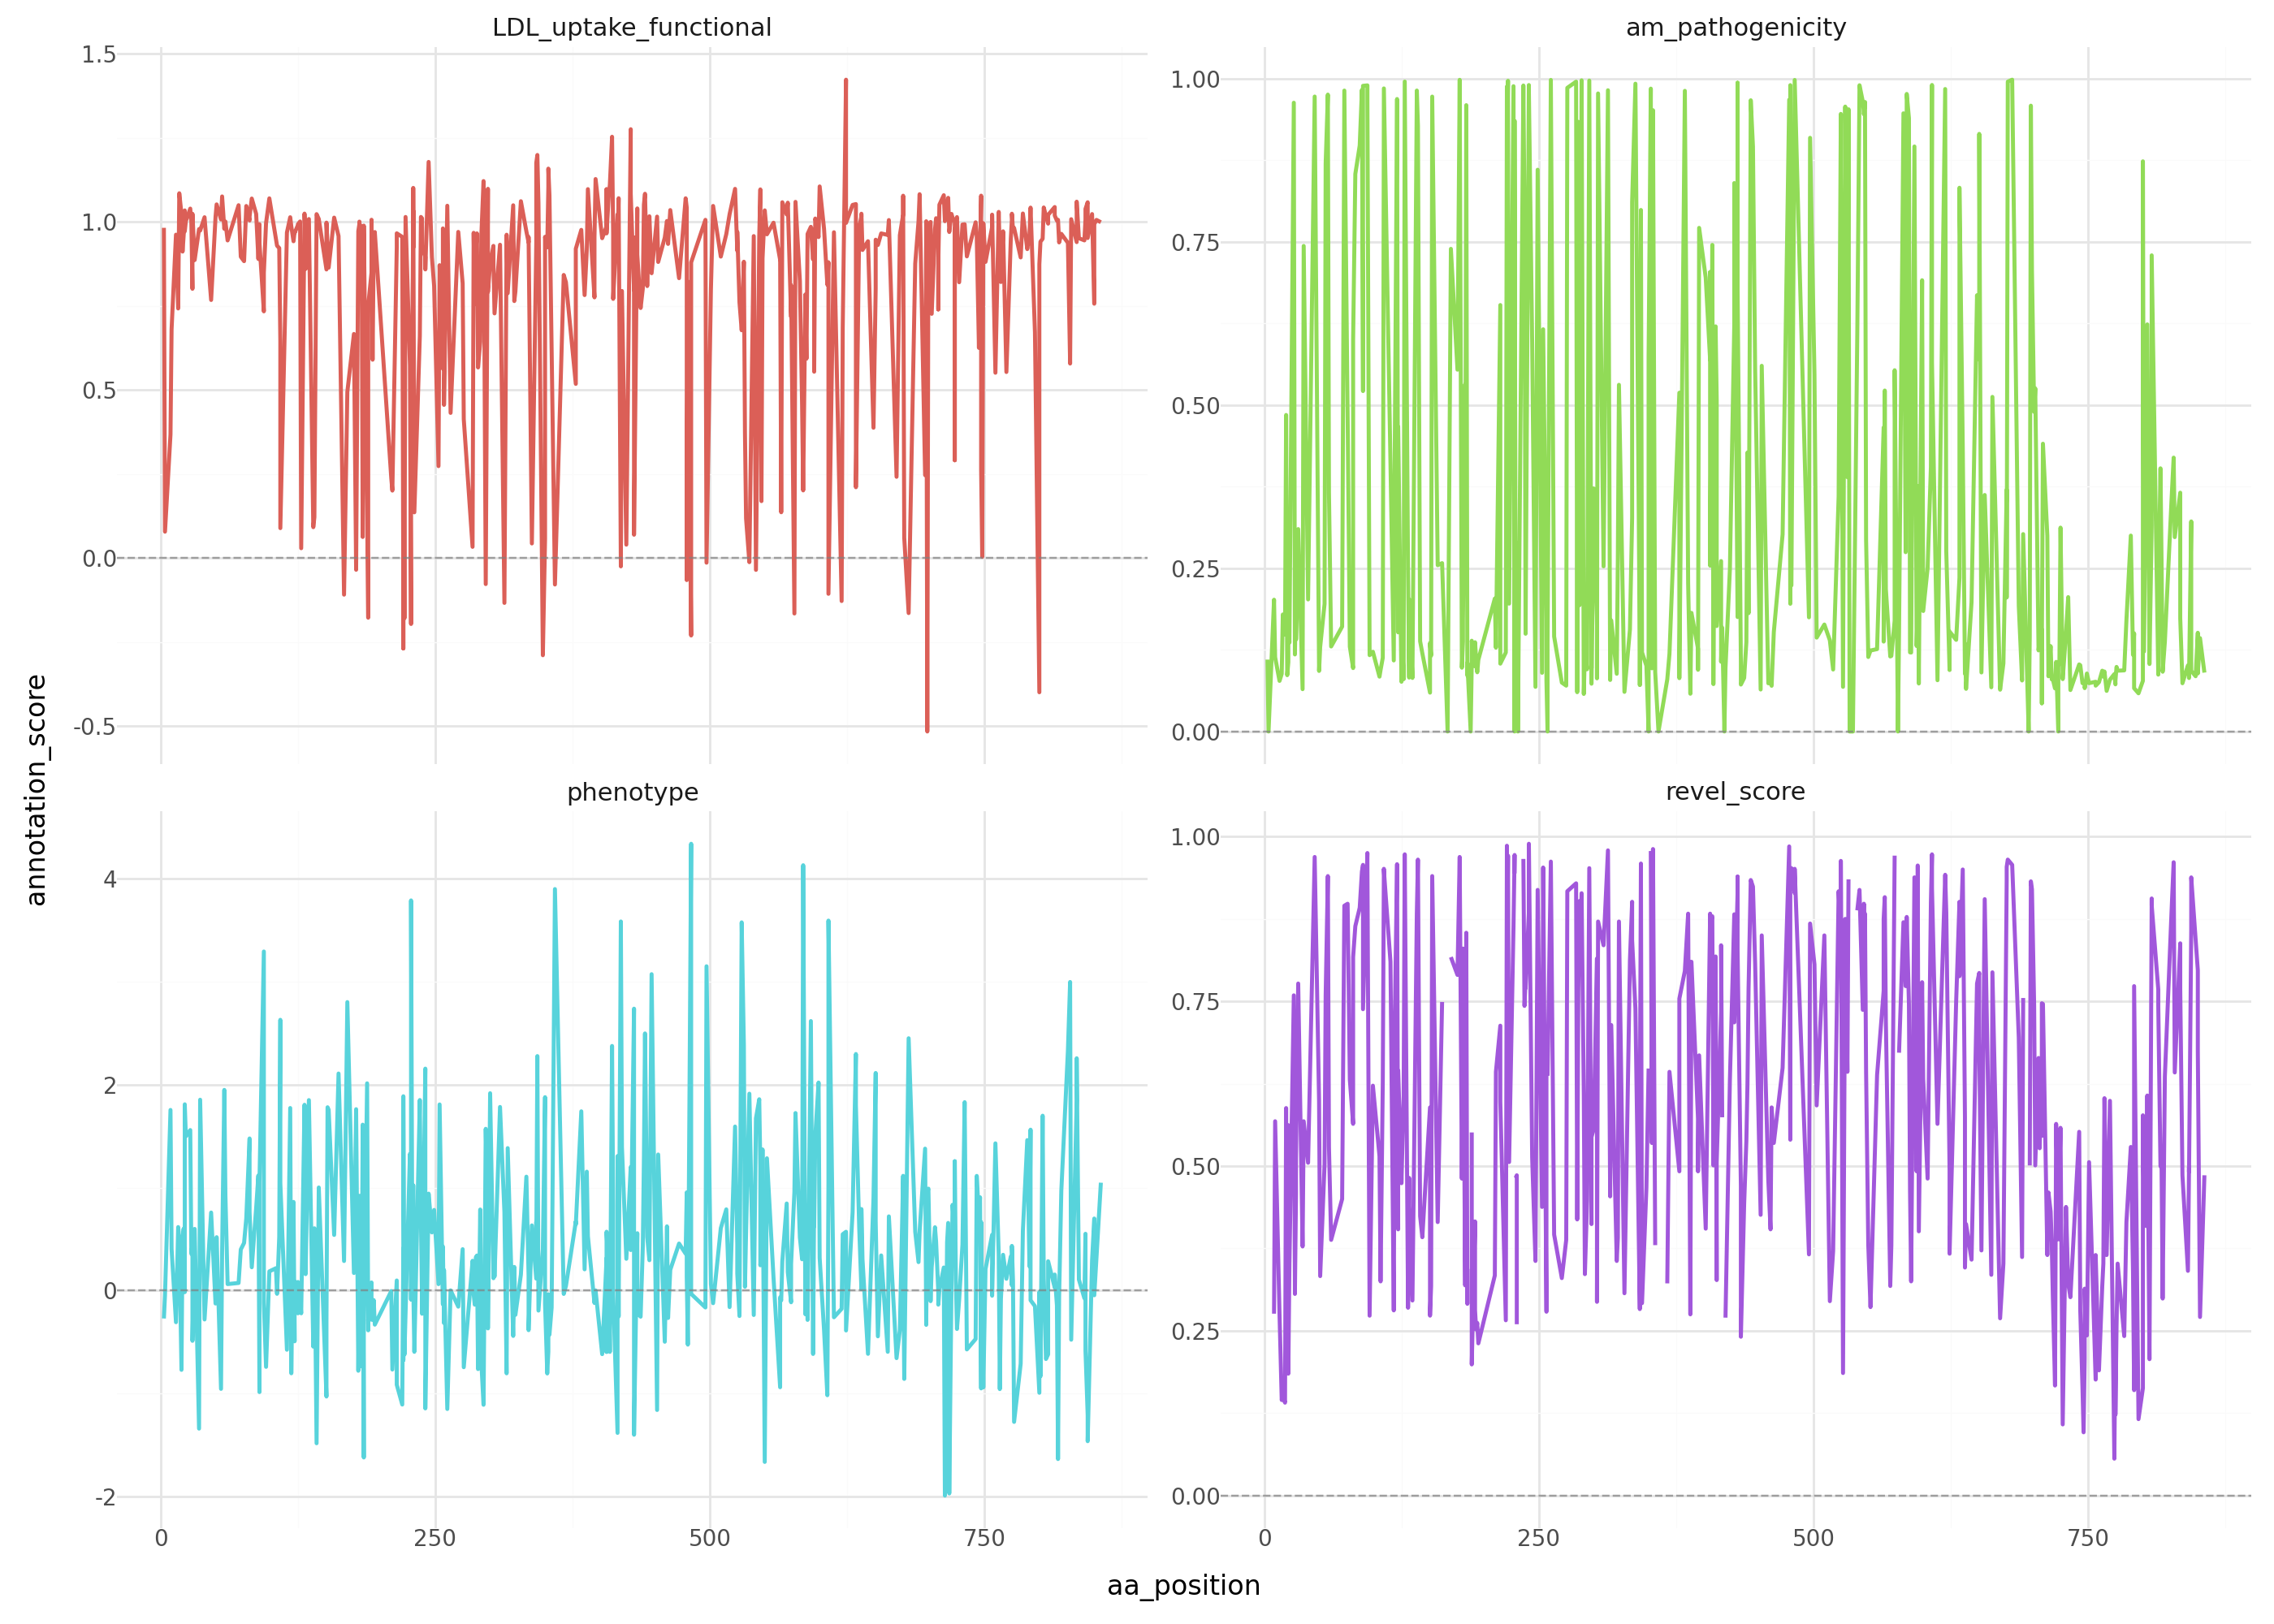

In [14]:
(
    ggplot(
        anno_df.filter(pl.col('annotation').is_in(['phenotype', assay2plot, 'am_pathogenicity', 'revel_score'])), 
        aes(x='aa_position', y='annotation_score', color='annotation')
    )
    + geom_line(size=1)
    + geom_hline(yintercept=0, linetype='dashed', color='grey', alpha=0.7)
    + facet_wrap("~annotation", ncol=2, scales="free_y")
    + theme_minimal()
    + theme(
        figure_size=(14, 10),
        legend_position="none",
        axis_text=element_text(size=10),
        axis_title=element_text(size=12),
        strip_text=element_text(size=11),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [15]:
# Get variant ID to amino acid position mapping from the annotation parquet
anno_with_pos = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .filter(
        pl.col('amino_acids').is_not_null(),
        pl.col('amino_acids').str.contains("/"),
        ~pl.col('protein_position').str.contains("-"),
        pl.col('region').is_in(gene_trait_df['region'].unique()),
    )
    .with_columns(
        pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
    )
    .select(['id', 'aa_position'])
    .unique()
    .collect()
)

# Add position to pre_corr_data
pre_corr_pos = pre_corr_data.join(anno_with_pos, on='id', how='inner')
print(f"Variants with position: {pre_corr_pos['id'].n_unique()} / {pre_corr_data['id'].n_unique()}")
print(f"Position range: {pre_corr_pos['aa_position'].min()} - {pre_corr_pos['aa_position'].max()}")
pre_corr_pos

/tmp/ipykernel_45947/3176608207.py:15: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


Variants with position: 398 / 398
Position range: 3 - 856


id,phenotype,mean_pheno_value,n_individuals,region,annotation,annotation_score,aa_position
str,str,f32,i32,str,str,f32,i64
"""chr19:11105470:C:G""","""ldl_direct_int""",2.011034,2,"""ENSG00000130164""","""cpt1_llr""",null,188
"""chr19:11105470:C:G""","""ldl_direct_int""",2.011034,2,"""ENSG00000130164""","""verphylop""",-0.151,188
"""chr19:11105470:C:G""","""ldl_direct_int""",2.011034,2,"""ENSG00000130164""","""esmscoremissense""",0.0,188
"""chr19:11105470:C:G""","""ldl_direct_int""",2.011034,2,"""ENSG00000130164""","""esm1b_llr""",null,188
"""chr19:11105470:C:G""","""ldl_direct_int""",2.011034,2,"""ENSG00000130164""","""cadd_raw""",3.922757,188
…,…,…,…,…,…,…,…
"""chr19:11116936:C:T""","""ldl_direct_int""",0.88713,13,"""ENSG00000130164""","""verphylop""",0.347,595
"""chr19:11116936:C:T""","""ldl_direct_int""",0.88713,13,"""ENSG00000130164""","""esmscoremissense""",-11.073,595
"""chr19:11116936:C:T""","""ldl_direct_int""",0.88713,13,"""ENSG00000130164""","""esm1b_llr""",-10.748,595


In [16]:
from sklearn.linear_model import LinearRegression

def compute_running_r2(df, window_size=100, step_size=1, min_variants=15):
    """
    Fit a global linear regression per annotation (annotation_score → mean_pheno_value),
    then compute local R² in each sliding window as 1 - SS_res / SS_tot.
    
    R² > 0: global model explains local variance well
    R² ≈ 0: no better than predicting the local mean
    R² < 0: global model is *worse* than the local mean (relationship breaks down)
    """
    results = []

    for annotation in df['annotation'].unique():
        anno_df = df.filter(pl.col('annotation') == annotation).sort('aa_position')

        positions = anno_df['aa_position'].to_numpy()
        scores = anno_df['annotation_score'].to_numpy().astype(np.float64)
        pheno = anno_df['mean_pheno_value'].to_numpy().astype(np.float64)

        # Valid mask (no NaNs)
        valid = ~np.isnan(scores) & ~np.isnan(pheno)
        if valid.sum() < 2:
            continue

        # Fit global linear regression: annotation_score → mean_pheno_value
        X_global = scores[valid].reshape(-1, 1)
        y_global = pheno[valid]
        model = LinearRegression().fit(X_global, y_global)

        # Sliding window R²
        pos_min, pos_max = int(positions.min()), int(positions.max())
        half_w = window_size // 2

        for center in range(pos_min + half_w, pos_max - half_w + 1, step_size):
            lo, hi = center - half_w, center + half_w
            mask = (positions >= lo) & (positions <= hi) & valid
            n = mask.sum()

            if n >= min_variants:
                y_win = pheno[mask]
                y_pred = model.predict(scores[mask].reshape(-1, 1))
                ss_res = np.sum((y_win - y_pred) ** 2)
                ss_tot = np.sum((y_win - y_win.mean()) ** 2)
                r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

                results.append({
                    'annotation': annotation,
                    'center_position': center,
                    'window_start': lo,
                    'window_end': hi,
                    'n_variants': int(n),
                    'r_squared': r2,
                    'global_slope': model.coef_[0],
                    'global_intercept': model.intercept_,
                })

    return pl.DataFrame(results)

# Parameters — adjust as needed
window_size = 100   # amino acid positions wide
step_size = 1       # slide by 1 position
min_variants = 15   # minimum variants per window

running_corr = compute_running_r2(
    pre_corr_pos,
    window_size=window_size,
    step_size=step_size,
    min_variants=min_variants,
)

# Join with annotation metadata for plotting
running_corr = (
    running_corr
    .join(anno_config_df.select(['annotation', 'label', 'color']), on='annotation')
)

print(f"Running R² results: {running_corr.shape}")
print(f"Annotations: {running_corr['annotation'].unique().to_list()}")
running_corr

Running R² results: (7540, 10)
Annotations: ['revel_score', 'LDLR_cell_surface_abundance', 'LDL_uptake_functional', 'gpn_score', 'verphylop', 'am_pathogenicity', 'cadd_raw', 'esmscoremissense', 'esm1b_llr', 'cpt1_llr']


annotation,center_position,window_start,window_end,n_variants,r_squared,global_slope,global_intercept,label,color
str,i64,i64,i64,i64,f64,f64,f64,str,str
"""LDLR_cell_surface_abundance""",53,3,103,44,-0.032987,-0.392738,0.750219,"""LDLR cell surface abundance""","""#81C784"""
"""LDLR_cell_surface_abundance""",54,4,104,43,-0.039831,-0.392738,0.750219,"""LDLR cell surface abundance""","""#81C784"""
"""LDLR_cell_surface_abundance""",55,5,105,43,-0.027435,-0.392738,0.750219,"""LDLR cell surface abundance""","""#81C784"""
"""LDLR_cell_surface_abundance""",56,6,106,44,-0.023016,-0.392738,0.750219,"""LDLR cell surface abundance""","""#81C784"""
"""LDLR_cell_surface_abundance""",57,7,107,44,-0.023016,-0.392738,0.750219,"""LDLR cell surface abundance""","""#81C784"""
…,…,…,…,…,…,…,…,…,…
"""revel_score""",802,752,852,49,0.038694,1.13676,-0.297042,"""REVEL""","""darkred"""
"""revel_score""",803,753,853,49,0.038694,1.13676,-0.297042,"""REVEL""","""darkred"""
"""revel_score""",804,754,854,49,0.038694,1.13676,-0.297042,"""REVEL""","""darkred"""


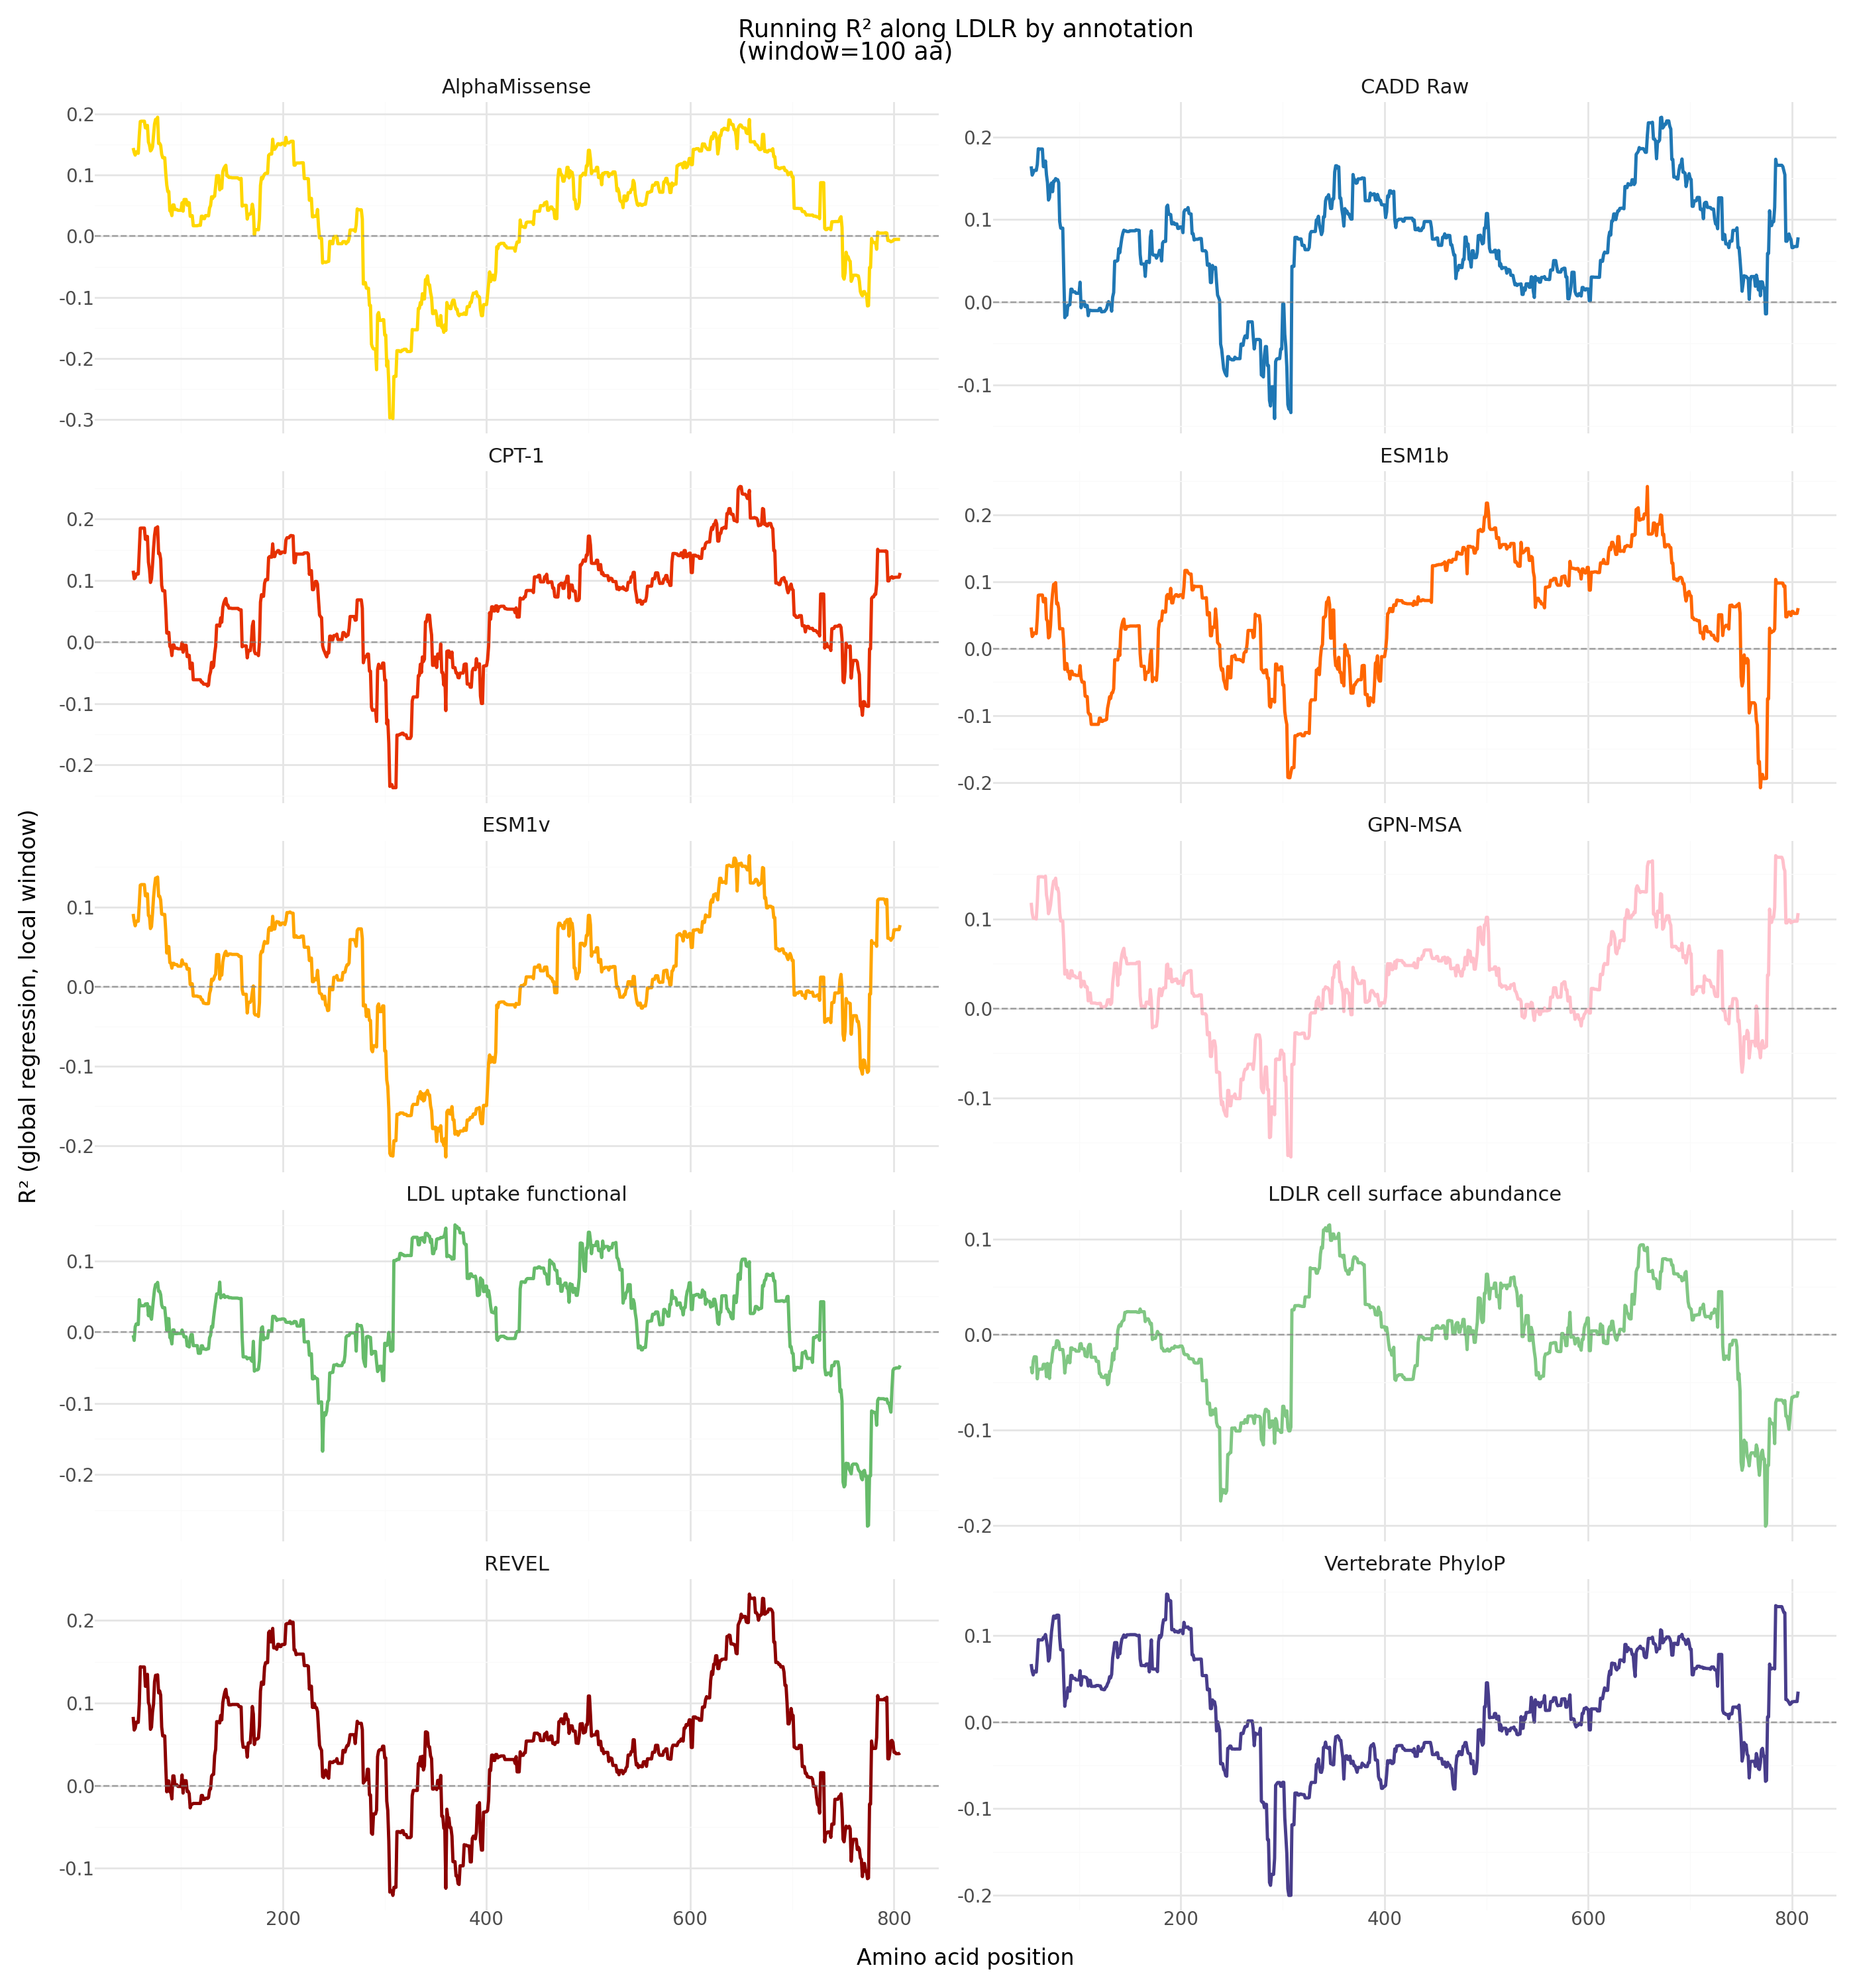

In [17]:
color_dict = dict(running_corr.select("label", "color").unique().iter_rows())

# Faceted plot: one panel per annotation for cleaner comparison
(
    ggplot(running_corr, aes(x="center_position", y="r_squared", color="label"))
    + geom_line(size=1)
    + geom_hline(yintercept=0, linetype='dashed', color='grey', alpha=0.7)
    + facet_wrap("~label", ncol=2, scales="free_y")
    + theme_minimal()
    + scale_color_manual(values=color_dict)
    + labs(
        x="Amino acid position",
        y="R² (global regression, local window)",
        title=f"Running R² along LDLR by annotation\n(window={window_size} aa)",
    )
    + theme(
        figure_size=(14, 3 * ((running_corr['label'].n_unique() + 1) // 2)),
        legend_position="none",
        axis_text=element_text(size=10),
        axis_title=element_text(size=12),
        strip_text=element_text(size=11),
        plot_background=element_rect(fill="white", color="white"),
    )
)

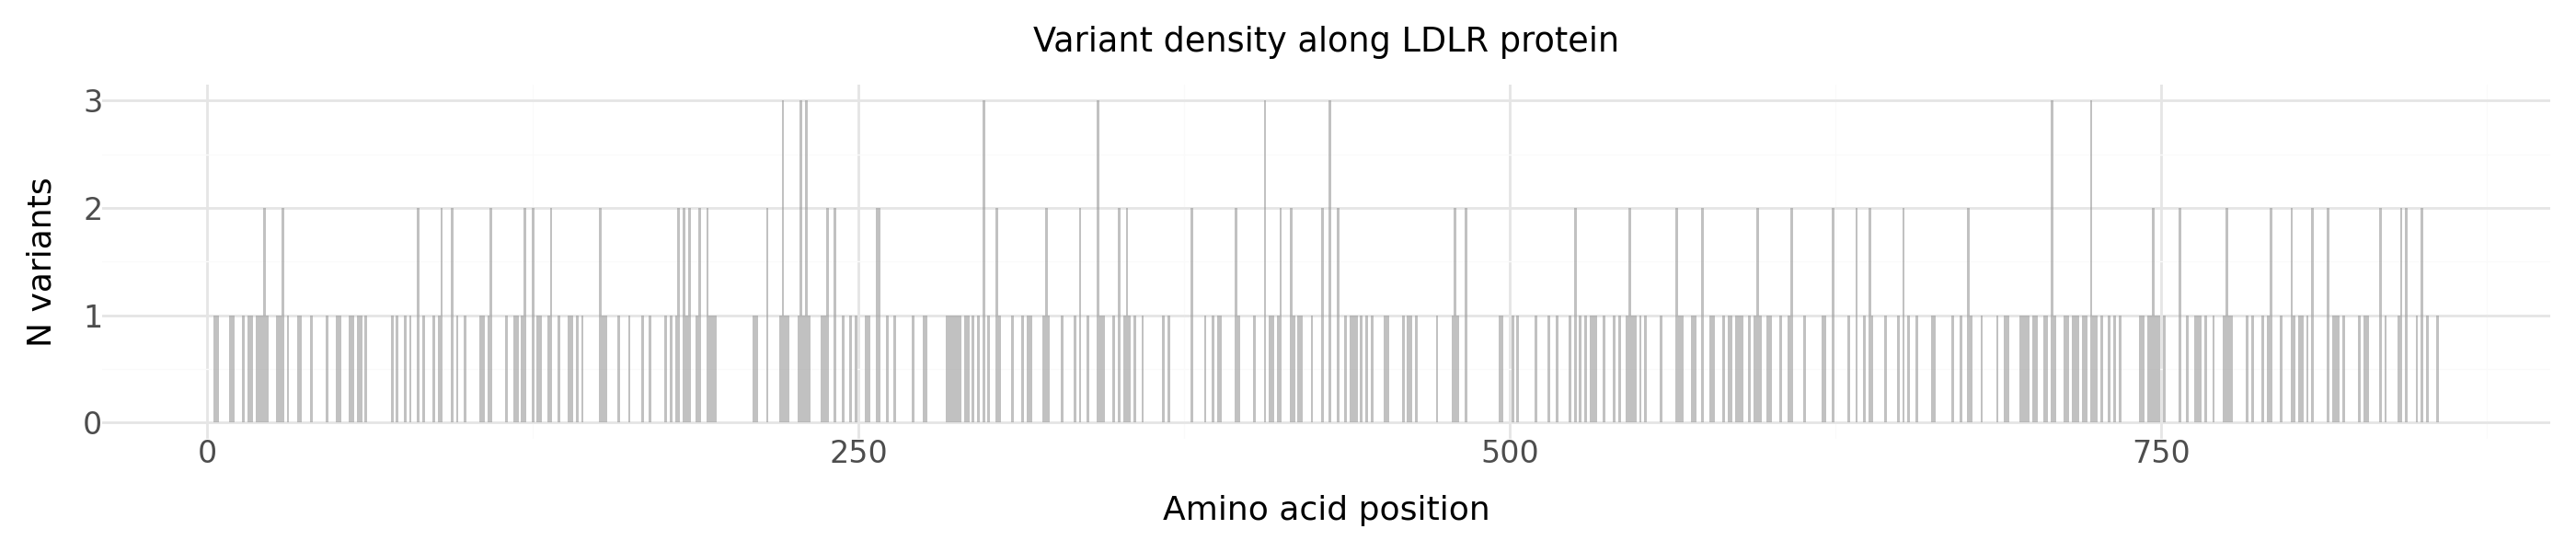

In [18]:
# Variant density along the protein (useful context for interpreting correlation dips)
# Uses the same pre_corr_pos data, taking one annotation to count unique variants per position
variant_positions = (
    pre_corr_pos
    .select(['id', 'aa_position'])
    .unique()
    .group_by('aa_position')
    .agg(n_variants=pl.len())
    .sort('aa_position')
)

(
    ggplot(variant_positions, aes(x="aa_position", y="n_variants"))
    + geom_col(fill="#999999", alpha=0.6, width=1)
    + theme_minimal()
    + labs(
        x="Amino acid position",
        y="N variants",
        title="Variant density along LDLR protein",
    )
    + theme(
        figure_size=(14, 3),
        axis_text=element_text(size=12),
        axis_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [20]:
# Extract domain annotations per amino acid position
domain_cols = ['mobi_full_disorder_priority', 'mobi_full_lip_priority', 'ted_domain', 'low_complexity_domain']

domain_df = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .filter(
        pl.col('amino_acids').is_not_null(),
        pl.col('amino_acids').str.contains("/"),
        ~pl.col('protein_position').str.contains("-"),
        pl.col('region').is_in(gene_trait_df['region'].unique()),
    )
    .with_columns(
        pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
    )
    .select(['aa_position'] + domain_cols)
    .group_by('aa_position')
    .agg([pl.col(c).max().alias(c) for c in domain_cols])  # any True at this position
    .sort('aa_position')
    .collect()
)

# Build contiguous domain intervals for plotting as horizontal bars
domain_labels = {
    'ted_domain': 'Structured Domain (TED)',
    'mobi_full_disorder_priority': 'Disordered Region',
    'mobi_full_lip_priority': 'Linear Interacting Peptide',
    'low_complexity_domain': 'Low Complexity',
}
domain_colors = {
    'ted_domain': '#2E8B57',
    'mobi_full_disorder_priority': '#E31A1C',
    'mobi_full_lip_priority': '#1E90FF',
    'low_complexity_domain': '#FF9933',
}

def get_intervals(positions, values):
    """Return list of (start, end) intervals where values are True."""
    intervals = []
    in_region = False
    for pos, val in zip(positions, values):
        if val and not in_region:
            start = pos
            in_region = True
        elif not val and in_region:
            intervals.append((start, prev_pos))
            in_region = False
        prev_pos = pos
    if in_region:
        intervals.append((start, prev_pos))
    return intervals

domain_intervals = {}
positions = domain_df['aa_position'].to_numpy()
for col in domain_cols:
    vals = domain_df[col].to_numpy().astype(bool)
    domain_intervals[col] = get_intervals(positions, vals)

print("Domain intervals:")
for col, intervals in domain_intervals.items():
    print(f"  {domain_labels[col]}: {intervals}")

/tmp/ipykernel_45947/3437448447.py:19: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


Domain intervals:
  Disordered Region: [(np.int64(4), np.int64(275)), (np.int64(354), np.int64(389)), (np.int64(409), np.int64(409)), (np.int64(416), np.int64(416)), (np.int64(459), np.int64(464)), (np.int64(475), np.int64(475)), (np.int64(714), np.int64(787))]
  Linear Interacting Peptide: [(np.int64(9), np.int64(16)), (np.int64(46), np.int64(62)), (np.int64(81), np.int64(106)), (np.int64(119), np.int64(144)), (np.int64(162), np.int64(184)), (np.int64(213), np.int64(231)), (np.int64(253), np.int64(271)), (np.int64(314), np.int64(344)), (np.int64(358), np.int64(362)), (np.int64(399), np.int64(399)), (np.int64(663), np.int64(663)), (np.int64(705), np.int64(705)), (np.int64(720), np.int64(725)), (np.int64(730), np.int64(732)), (np.int64(753), np.int64(770)), (np.int64(783), np.int64(829))]
  Structured Domain (TED): [(np.int64(210), np.int64(249)), (np.int64(284), np.int64(335)), (np.int64(399), np.int64(653))]
  Low Complexity: [(np.int64(791), np.int64(808))]


In [21]:
running_corr['annotation'].unique()

annotation
str
"""esm1b_llr"""
"""cadd_raw"""
"""cpt1_llr"""
"""revel_score"""
"""esmscoremissense"""
"""gpn_score"""
"""verphylop"""
"""LDLR_cell_surface_abundance"""
"""LDL_uptake_functional"""


/tmp/ipykernel_45947/2338955472.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


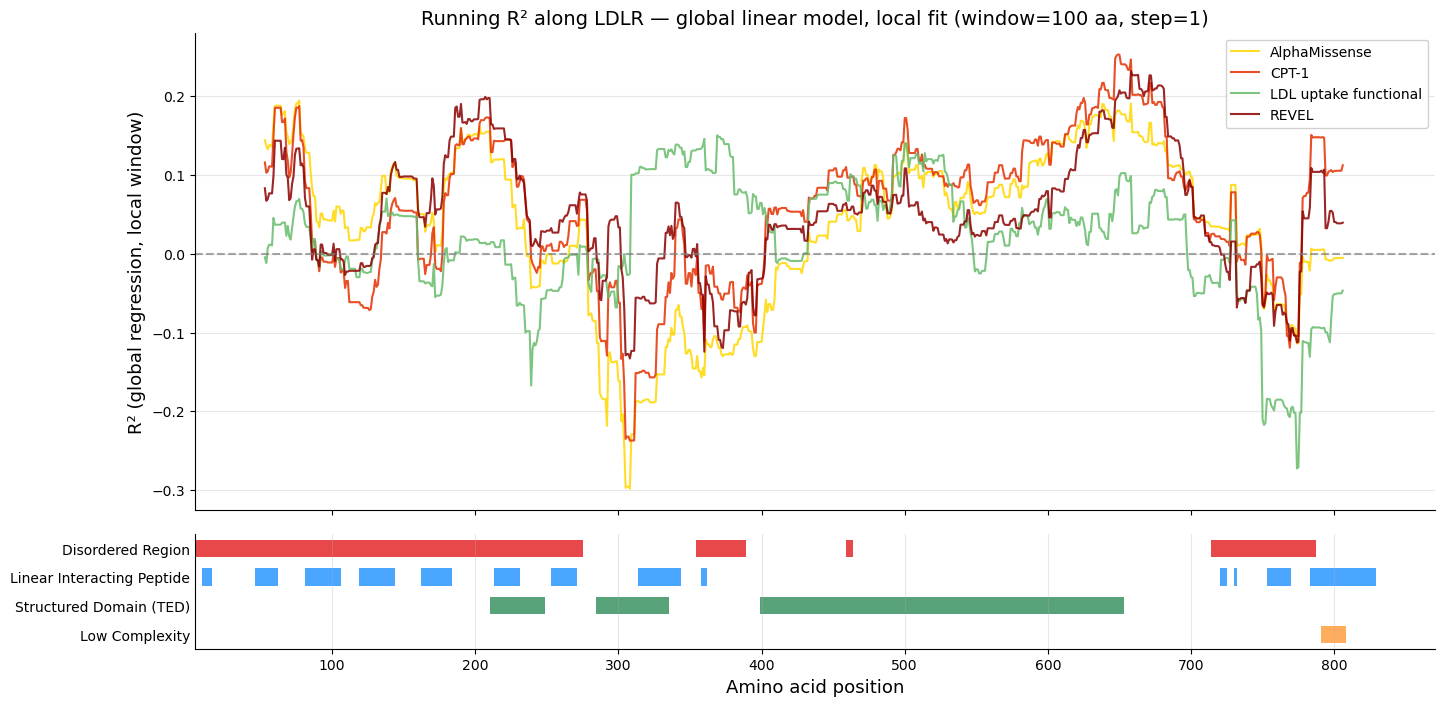

In [23]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec


annos2plot = ['am_pathogenicity', 'cpt1_llr', 'revel_score', assay2plot]
running_corr_plot = (
    running_corr
    .filter(pl.col('annotation').is_in(annos2plot))
)

# Build the combined figure: running R² + domain track
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(2, 1, height_ratios=[5, 1.2], hspace=0.08)

ax_corr = fig.add_subplot(gs[0])
ax_dom = fig.add_subplot(gs[1], sharex=ax_corr)

# --- Top panel: running R² ---
color_dict_label = dict(running_corr_plot.select("label", "color").unique().iter_rows())

for label in running_corr_plot['label'].unique().sort():
    sub = (
        running_corr_plot
        .filter(pl.col('label') == label)
        .sort('center_position')
    )
    ax_corr.plot(
        sub['center_position'].to_numpy(),
        sub['r_squared'].to_numpy(),
        label=label,
        color=color_dict_label[label],
        linewidth=1.5,
        alpha=0.85,
    )

ax_corr.axhline(0, color='grey', linestyle='--', alpha=0.7)
ax_corr.set_ylabel("R² (global regression, local window)", fontsize=13)
ax_corr.set_title(
    f"Running R² along LDLR — global linear model, local fit (window={window_size} aa, step={step_size})",
    fontsize=14,
)
ax_corr.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax_corr.tick_params(axis='x', labelbottom=False)
ax_corr.grid(axis='y', alpha=0.3)

# --- Bottom panel: domain track ---
track_height = 0.6
active_domains = [col for col in domain_cols if len(domain_intervals[col]) > 0]

for i, col in enumerate(active_domains):
    y_center = i
    for start, end in domain_intervals[col]:
        ax_dom.barh(
            y_center, end - start, left=start,
            height=track_height,
            color=domain_colors[col],
            edgecolor='none',
            alpha=0.8,
        )

ax_dom.set_yticks(range(len(active_domains)))
ax_dom.set_yticklabels([domain_labels[c] for c in active_domains], fontsize=10)
ax_dom.set_xlabel("Amino acid position", fontsize=13)
ax_dom.set_ylim(-0.5, len(active_domains) - 0.5)
ax_dom.invert_yaxis()
ax_dom.tick_params(axis='y', length=0)
ax_dom.grid(axis='x', alpha=0.3)

# Clean up spines
for ax in [ax_corr, ax_dom]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()